### Pre-training의 첫번째 관문
- 데이터의 역활 : 다다익선 
- 데이터처리 파이프라인
    - 원본 텍스트 데이터
        - 1단계 : 필터링(스팸, 저품질 제거)
        - 2단계 : 중복제거
        - 3단계 : 정규화
        - 4단계 : 토큰화
    - 훈련가능한 데이터
- 토큰화 : 텍스트를 모델이 이해할수 있는 정수 시퀀스로 변환하는 과정
    - 1. 전처리
        - 공백표준화
        - 특수문자처리
        - 케이스통일
    - 2. 어휘선택
        - Character-level : 문자단위(너무 길어짐)
        - Word-level : 단어단위(어휘크기 폭증)
        - Subword-level : n-gram (GPT 계열) --> 가장 효율적
    - 3. 어휘사전
        - 가장 자주나타나는 시퀀스 학습(playing = play + ing)
- Byte-Pair Encoding(BPE)
    - 1. 초기 단어 분해
        hello word -> [h, e , l ....]
    - 2. 가장 빈번한 바이트 쌍 병합
        반복 1 : ('l', 'l') -> 'll'
        반복 2 : ('h', 'e') -> 'he'
        반복 3 : ('w', 'o') -> 'wo'
        ...
    - 3. 병합규칙 저장
        merge_rules = {
            ('l','l') : 'B1'
            ...
        }
    - 4. 어휘생성(단어사전 vocabulary)
        vocab = ['h','e',,, 'll','he']




#### BPE의 장점
1. **어휘 크기 조절 가능**: 50K ~ 200K 범위에서 유연함
2. **미지의 단어 처리**: OOV(Out-of-Vocabulary) 거의 발생하지 않음
3. **효율성**: 긴 문장을 적정 길이로 압축

### 4. 토큰화가 성능에 미치는 영향

#### 예시 1: "PlayGround"
- **나쁜 토큰화**: ['P', 'l', 'a', 'y', 'G', 'r', 'o', 'u', 'n', 'd'] (10개)
- **좋은 토큰화**: ['Play', 'Ground'] (2개)
- **영향**: 입력 길이 감소 → 모델이 더 넓은 맥락 볼 수 있음

#### 예시 2: 다국어 처리
- 영어: 효율적 토큰화 가능
- 한국어/중국어: 문자 단위에 가까워야 함 (언어별 토크나이저 필요)

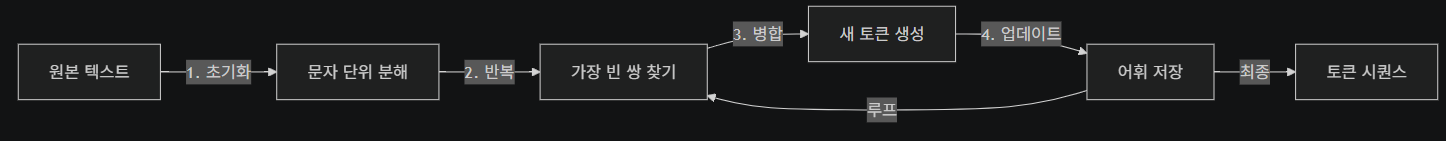

In [2]:
from collections import Counter, defaultdict
import re
from typing import List, Dict, Tuple
import pandas as pd
import matplotlib.pyplot as plt
# 재현성
import random
random.seed(42)

In [ ]:
# 작은 말뭉치
corpus = [
    "hello world hello there",
    "hello beautiful world",
    "the quick brown fox",
    "the lazy dog",
    "hello hello",
    "world peace"
]
class BPETokenizer:
    '''
    BPE(Byte-Pair-Encoding)

    작동:
    1. 텍스트를 문자 단위로 분해
    2. 가장 자주 나타나는 인접한 쌍(pair)을 찾음
    3. 그 쌍을 하나의 새 토큰으로 병합
    4. 2-3을 반복해서 어휘크기를 조절
    '''
    def __init__(self):
        self.word_freqs = defaultdict(int) # 단어빈도
        self.merge = {}  # 병합규칙(pair) -> new token
        self.vocab = set() # 현재 어휘
        self.mege_history = []  # 병합과정 기록
    def build_initial_vocab(self, corpus:List[str]):
        '''step 1 : 텍스트를 단어어로 분해하고 문자 단위로 분리'''
        for text in corpus:
            words = text.split()
            for word in words:
                self.word_freqs[word] += 1
        
        # 초기어휘 : 모든 문자
        for word in self.word_freqs:
            for char in word:
                self.vocab.add(char)
        self.vocab.add('</w>')  # 특수토큰 : 단어 끝을 표시(GPT 스타일)
        return self
    
    def get_stats(self, vocab:Dict[str,int]) -> Dict[Tuple[str,str], int]:
        '''각(pair) 조합의 빈도를 계산'''
        pairs = defaultdict(int)
        for word, freq in vocab.items():
            symbols = word.split()
            for i in range(len(symbols)-1):
                pairs[symbols[i], symbols[i+1]] += freq              
        return pairs
    def merge_vocab(self, pair:Tuple[str,str], vocab:Dict[str,int]) -> Dict[str,int]:
        '''특정 pair를 하나의 토큰으로 병합'''
        new_vocab = {}
        bigram =' '.join(pair)
        replacement = ''.join(pair)
        for word in vocab:
            new_word = word.replace(bigram, replacement)
            new_vocab[new_word] = vocab[word]
        return new_vocab
    def train(self, corpus: List[str], num_merges: int = 10):
        """BPE 훈련: num_merges 번만큼 반복"""
        self.build_initial_vocab(corpus)
        
        # 초기 vocab dict 생성
        vocab = {}
        for word, freq in self.word_freqs.items():
            # m3_parameter_tensor_explanation: 각 문자 사이에 공백 추가
            vocab[' '.join(word) + ' </w>'] = freq
        
        print(f"[초기 어휘 크기] {len(self.vocab)}")
        print(f"[병합 시작] {num_merges}번 반복\n")
        
        for i in range(num_merges):
            pairs = self.get_stats(vocab)
            
            if not pairs:
                print(f"  반복 {i+1}: 병합 가능한 pair가 없음. 중단.")
                break
            
            best_pair = max(pairs, key=pairs.get)
            best_freq = pairs[best_pair]
            
            # m7_output_symbol_analysis: 각 병합 단계 상세 기록
            vocab = self.merge_vocab(best_pair, vocab)
            self.merges[best_pair] = ''.join(best_pair)
            new_token = ''.join(best_pair)
            self.vocab.add(new_token)
            
            merge_record = {
                'iteration': i + 1,
                'pair': f"('{best_pair[0]}', '{best_pair[1]}')",
                'frequency': best_freq,
                'new_token': new_token,
                'vocab_size': len(self.vocab)
            }
            self.merge_history.append(merge_record)
            
            print(f"  반복 {i+1}: {best_pair} → '{new_token}' (빈도: {best_freq})")
        
        print(f"\n[최종 어휘 크기] {len(self.vocab)}")
        return self

defaultdict(int, {('hello', 'word'): 2})